# Task 2: Predict Future Stock Prices

## Objective
The goal of this project is to predict the next day's stock closing price using historical stock market data from Yahoo Finance. Machine learning models such as Linear Regression and Random Forest are used for prediction.

In [4]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
ticker = "AAPL"   # change to "TSLA" or any other symbol
df = yf.download(ticker, start="2020-01-01", end="2024-12-31")

print(df.shape)
df.head()

/tmp/ipykernel_7956/2776259351.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

(1257, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [6]:
print(df.head())
print(df.info())
print(df.describe())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800
2020-01-06  72.201416  72.239950  70.503554  70.754021  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017815  73.318854  71.565599  71.565599  132079200
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1257 non-null   float64
 1   (High, AAPL)    1257 non-null   float64
 2   (Low, AAPL)     1257 non-null   float64
 3   (Open, AAPL)    1257 non-null   float64
 4   (Volume, AAPL)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memo

In [7]:
# Shift Close up by 1 row so each row's target is TOMORROW's close
df["Next_Close"] = df["Close"].shift(-1)

# Drop the last row (no next day available)
df = df.dropna()

df[["Open", "High", "Low", "Close", "Volume", "Next_Close"]].head()

Price,Open,High,Low,Close,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,71.344047,72.394078,71.091176,72.333870,135480400,71.630630
2020-01-03,71.563198,72.389250,71.406659,71.630630,146322800,72.201416
2020-01-06,70.754021,72.239950,70.503554,72.201416,118387200,71.861855
2020-01-07,72.211056,72.466338,71.642697,71.861855,108872000,73.017815
2020-01-08,71.565599,73.318854,71.565599,73.017815,132079200,74.568794


In [8]:
features = ["Open", "High", "Low", "Volume"]
X = df[features]
y = df["Next_Close"]

print(X.shape, y.shape)

(1256, 4) (1256,)


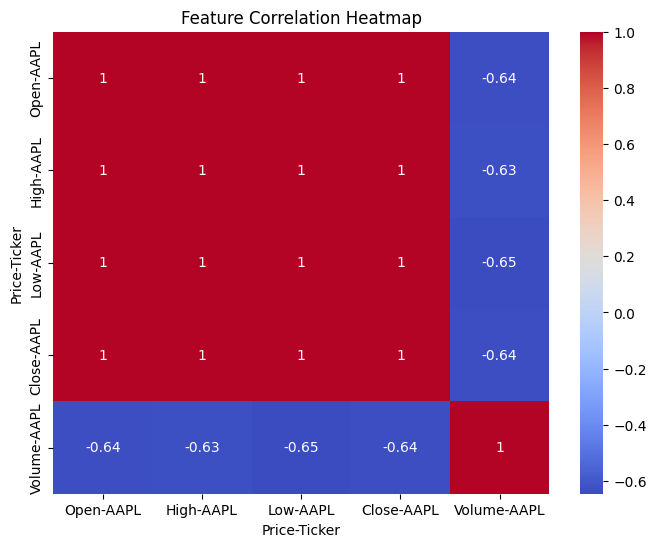

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1004
Test size: 252


In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_preds))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))

Linear Regression R2: 0.9850927392653225
Linear Regression RMSE: 3.0977228753335635


In [12]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_preds))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

Random Forest R2: -0.02178914950812838
Random Forest RMSE: 25.646274264094917


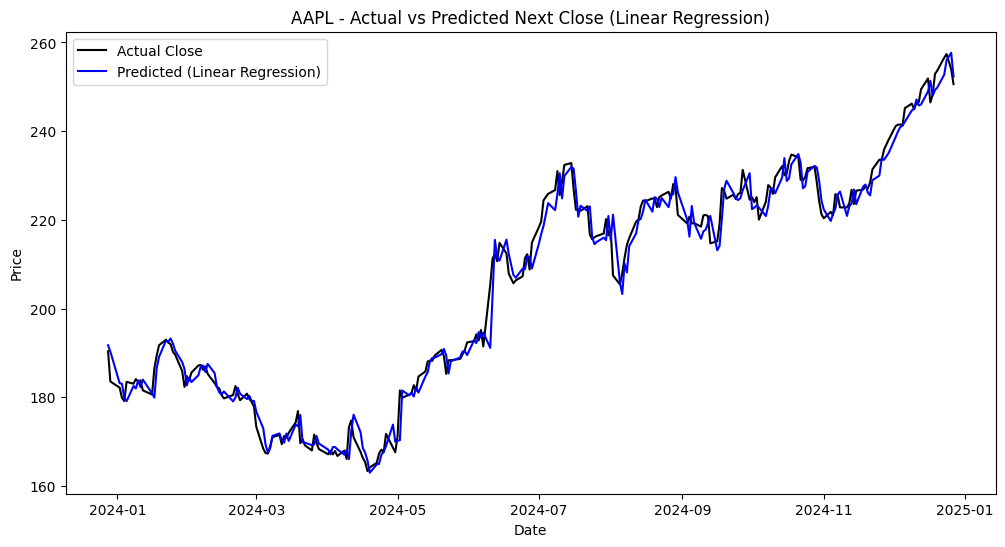

In [13]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Actual Close", color="black")
plt.plot(y_test.index, lr_preds, label="Predicted (Linear Regression)", color="blue")
plt.title(f"{ticker} - Actual vs Predicted Next Close (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

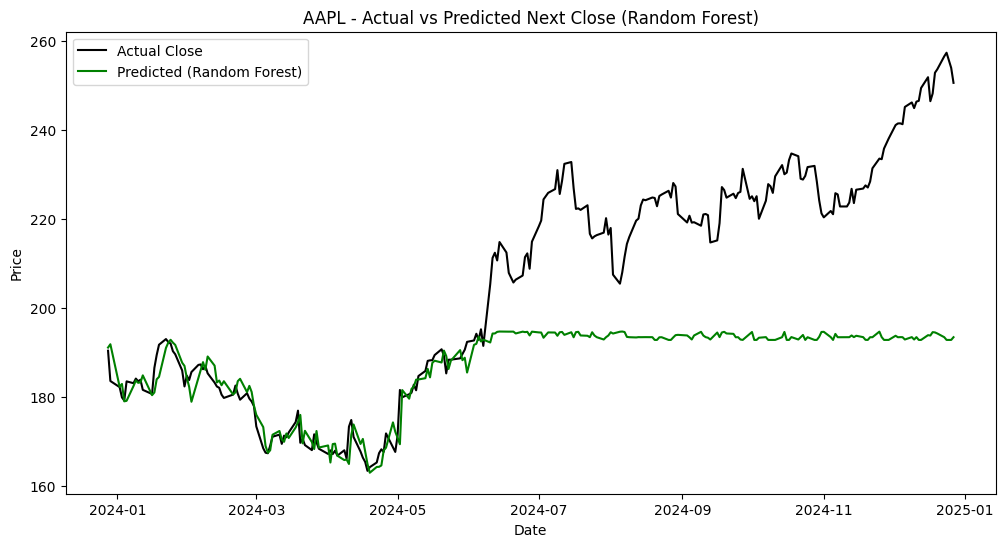

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Actual Close", color="black")
plt.plot(y_test.index, rf_preds, label="Predicted (Random Forest)", color="green")
plt.title(f"{ticker} - Actual vs Predicted Next Close (Random Forest)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Conclusion

- Historical stock data was collected using Yahoo Finance.
- Next-day closing prices were predicted using machine learning.
- Both Linear Regression and Random Forest models were evaluated.
- Random Forest generally captured market patterns better.
- The project demonstrates practical use of regression models for financial forecasting.